# Εργαστήριο 1: Ανάπτυξη Συστήματος Υποστήριξης Αποφάσεων (DSS) με την Python
## Το Σενάριο (Business Problem)
Είστε ο Tactical Manager μιας μεγάλης αλυσίδας ξενοδοχείων. Το πρόβλημα που καλείστε να λύσετε είναι το υψηλό ποσοστό **Ακυρώσεων Κρατήσεων (Cancellations)**, το οποίο προκαλεί τεράστια απώλεια εσόδων. 
https://www.kaggle.com/datasets/bravehart101/sample-supermarket-dataset


Στόχος αυτού του εργαστηρίου είναι να εφαρμόσουμε το μοντέλο του **Herbert Simon**:
1. **Intelligence:** Θα φορτώσουμε και θα καθαρίσουμε τα ιστορικά δεδομένα (Data Cleaning).
2. **Design:** Θα αναλύσουμε τα πρότυπα συμπεριφοράς των πελατών (Correlation, What-If).
3. **Choice:** Θα προτείνουμε συγκεκριμένες πολιτικές (πολυπλοκότητα εγγυήσεων, όρια χρόνου) για να μειώσουμε τις ακυρώσεις.

### Τα Εργαλεία μας (Python Libraries)
Σε ένα Σύστημα Υποστήριξης Αποφάσεων (DSS), χρειαζόμαστε εργαλεία για να μετατρέψουμε τα ακατέργαστα δεδομένα σε χρήσιμη πληροφορία. Στην Python, αυτό γίνεται κυρίως με 3 βιβλιοθήκες:

1. **Pandas (`pd`)**: Είναι το "έξυπνο Excel" της Python. Μας επιτρέπει να φορτώνουμε τεράστια σύνολα δεδομένων (DataFrames), να τα φιλτράρουμε, να τα ομαδοποιούμε και να τα μετασχηματίζουμε με λίγες γραμμές κώδικα.
2. **Matplotlib (`plt`)**: Η βασική βιβλιοθήκη για τη δημιουργία γραφημάτων. Μας δίνει τον απόλυτο έλεγχο πάνω σε κάθε στοιχείο (άξονες, τίτλοι, χρώματα).
3. **Seaborn (`sns`)**: Χτίζεται πάνω στην Matplotlib, αλλά έχει δημιουργηθεί ειδικά για στατιστική ανάλυση. Με τη Seaborn μπορούμε να φτιάξουμε εντυπωσιακά και πολύπλοκα γραφήματα (όπως Heatmaps) πολύ εύκολα, βοηθώντας τον Tactical Manager να δει αμέσως τα μοτίβα.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Φόρτωση του dataset (Hotel Booking Demand από το Kaggle)
df = pd.read_csv('hotel_bookings.csv')

## Intelligence Phase: Γνωριμία με τα Δεδομένα
### Βήμα 1: Έλεγχος των Δεδομένων (Data Inspection)
Πριν ξεκινήσουμε την ανάλυση, πρέπει να "γνωρίσουμε" τα δεδομένα μας. Στη Λήψη Αποφάσεων δεν μπορούμε να προχωρήσουμε αν δεν κατανοήσουμε το περιβάλλον του προβλήματος (Intelligence Phase). 

Οι βασικές ερωτήσεις που κάνουμε στα δεδομένα μας μέσω της Pandas είναι:
* `df.shape`: Πόσες παραγγελίες/κρατήσεις (γραμμές) και πόσα χαρακτηριστικά (στήλες) έχουμε;
* `df.info()`: Τι τύπου είναι τα δεδομένα μας; Έχουμε κείμενο, αριθμούς ή ημερομηνίες; Λείπουν τιμές;
* `df.describe()`: Ποια είναι η στατιστική εικόνα; Ποιος είναι ο μέσος όρος, η μέγιστη και η ελάχιστη τιμή σε κάθε στήλη; 
* `df.head()`: Πώς μοιάζουν οι πρώτες 5 γραμμές του πίνακα για να έχουμε μια οπτική επαφή;

In [ ]:
# Προεπισκόπηση των Δεδομένων

# Βασικές Εντολές Εξερεύνησης:
# ------------------------------
# 1. Διαστάσεις του DataFrame (γραμμές x στήλες)
df.shape

# 2. Εκτύπωση συνόλου εγγραφών
#print(f"Σύνολο εγγραφών: {df.shape[0]}")

# 3. Προβολή των πρώτων 3 εγγραφών
#df[:3]

# 4. Προβολή των τελευταίων 3 εγγραφών
#df[-3:]

# 5. Στατιστική περίληψη όλων των αριθμητικών στηλών
#    (count, mean, std, min, 25%, 50%, 75%, max)
df.describe()

# 6. Εμφάνιση ονομάτων όλων των στηλών
#df.columns

# 7. Εμφάνιση των πρώτων 5 γραμμών
#df.head()

# 8. Εμφάνιση των κλειδιών (ίδιο με columns)
#df.keys()

# 9. Μοναδικές τιμές της στήλης 'hotel' (π.χ. Resort Hotel, City Hotel)
#df['hotel'].unique()

# 10. Στατιστική περίληψη μόνο για τη στήλη 'lead_time'
#df['lead_time'].describe()

# 11. Συχνότητα εμφάνισης των 10 πρώτων τιμών lead_time
#df['lead_time'].value_counts().loc[:10]


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Βήμα 2: Καθαρισμός Δεδομένων (Data Cleaning) - Ο Κανόνας GIGO

Στα Ευφυή Συστήματα και τη Λήψη Αποφάσεων κυριαρχεί ένας αμείλικτος κανόνας: **GIGO (Garbage In, Garbage Out)**. Αν τροφοδοτήσουμε το σύστημά μας με ελλιπή, λανθασμένα ή "βρώμικα" δεδομένα, οι προβλέψεις και οι αποφάσεις που θα μας προτείνει θα είναι εξίσου λανθασμένες, κοστίζοντας χρήματα στην επιχείρηση.

Πριν αναλύσουμε τις ακυρώσεις των ξενοδοχείων (`is_canceled`), πρέπει να διασφαλίσουμε την **Ποιότητα των Δεδομένων (Data Quality)** ελέγχοντας 3 βασικούς πυλώνες:

1. **Αντιμετώπιση Κενών Τιμών (Missing Values / NaNs):** - Στα δεδομένα του πραγματικού κόσμου πάντα λείπουν καταχωρήσεις. 
   - *Παράδειγμα:* Αν λείπει η χώρα (`country`) του πελάτη, δεν διαγράφουμε ολόκληρη την κράτηση γιατί θα χάσουμε πληροφορία. Αντικαθιστούμε το κενό με μια ετικέτα όπως `'Unknown'`. Αν λείπει ο αριθμός των παιδιών (`children`), υποθέτουμε ότι είναι `0`.

2. **Διόρθωση Τύπων Δεδομένων (Data Typing):**
   - Τα συστήματα συχνά μπερδεύουν τους αριθμούς με κείμενο. 
   - *Παράδειγμα:* Ο αριθμός των παιδιών δεν μπορεί να έχει δεκαδικά (float). Πρέπει να τον μετατρέψουμε αυστηρά σε ακέραιο (integer).

3. **Λογικός Έλεγχος & Ανωμαλίες (Logical Errors / Anomalies):**
   - Ψάχνουμε για εγγραφές που είναι πρακτικά αδύνατες (Business Logic).
   - *Παράδειγμα:* Μια κράτηση δωματίου που έχει 0 ενήλικες, 0 παιδιά και 0 μωρά είναι προφανώς κάποιο "σκουπίδι" ή σφάλμα του συστήματος κρατήσεων και πρέπει να αφαιρεθεί εντελώς.

In [7]:
# --- ΒΗΜΑ 1: Έλεγχος του προβλήματος ---
print("--- 1. Έλεγχος Κενών Τιμών πριν τον καθαρισμό ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Δείχνει μόνο τις στήλες που έχουν κενά

# --- ΒΗΜΑ 2: Διαχείριση Κενών Τιμών (Missing Values) ---
# Αντικαθιστούμε τις κενές χώρες με τη λέξη 'Unknown'
if 'country' in df.columns:
    df['country'] = df['country'].fillna('Unknown')

# Αντικαθιστούμε τα κενά στα παιδιά (children) με 0
if 'children' in df.columns:
    df['children'] = df['children'].fillna(0)

# --- ΒΗΜΑ 3: Διόρθωση Τύπων Δεδομένων (Casting) ---
# Κάνουμε τον αριθμό των παιδιών ακέραιο (από 1.0 σε 1)
if 'children' in df.columns:
    df['children'] = df['children'].astype(int)

# --- ΒΗΜΑ 4: Διαγραφή Λογικών Σφαλμάτων (Business Logic) ---
# Βρίσκουμε τις κρατήσεις που δεν έχουν ούτε έναν επισκέπτη
zero_guests = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
print(f"\n--- 2. Λογικός Έλεγχος ---")
print(f"Βρέθηκαν {zero_guests.sum()} κρατήσεις-φαντάσματα (χωρίς κανέναν πελάτη).")

# Διατηρούμε στο DataFrame ΜΟΝΟ όσες εγγραφές ΔΕΝ είναι zero_guests
df = df[~zero_guests]

print("\n--- 3. Τελικό Αποτέλεσμα ---")
print(f"Ο καθαρισμός ολοκληρώθηκε! Διαστάσεις καθαρού DataFrame: {df.shape}")


--- 1. Έλεγχος Κενών Τιμών πριν τον καθαρισμό ---
children         4
country        488
agent        16340
company     112593
dtype: int64

--- 2. Λογικός Έλεγχος ---
Βρέθηκαν 180 κρατήσεις-φαντάσματα (χωρίς κανέναν πελάτη).

--- 3. Τελικό Αποτέλεσμα ---
Ο καθαρισμός ολοκληρώθηκε! Διαστάσεις καθαρού DataFrame: (119210, 32)


## Design Phase: Ανάλυση και Μοντελοποίηση
### Η Μεθοδολογία Επίλυσης: Από το Πρόβλημα στη Λύση
Τώρα που έχουμε καθαρά δεδομένα, πώς σκεφτόμαστε ως Στελέχη Ή Μηχανικοί Γνώσης για να λύσουμε το πρόβλημα των κρατήσεων ξενοδοχείων (Hotel Cancellations); 

Βασιζόμαστε στο Μοντέλο του **Herbert Simon**:
1. **Intelligence Phase (Αναζήτηση Προβλήματος)**: Στόχος μας είναι να βρούμε *γιατί* γίνονται ακυρώσεις. Ποια είναι η μεταβλητή-στόχος (Target Variable); Είναι το `is_canceled`. 
2. **Design Phase (Σχεδιασμός)**: Αντί να κοιτάμε ατελείωτους πίνακες, σχεδιάζουμε ένα γράφημα. Στην προκειμένη περίπτωση, ελέγχουμε τη **Συσχέτιση (Correlation)**: ποιες άλλες μεταβλητές (π.χ. χρόνος αναμονής `lead_time`, προκαταβολή `deposit_type`) συνδέονται στενά με την ακύρωση;
3. **Οπτικοποίηση (Tornado Chart)**: Ταξινομούμε αυτούς τους παράγοντες από τον πιο επιδραστικό στον λιγότερο επιδραστικό. Το γράφημα "Ανεμοστρόβιλος" (Tornado Chart) είναι ένα ισχυρό εργαλείο Sensitivity Analysis (Ανάλυση Ευαισθησίας) στα DSS. 
4. **Choice Phase (Επιλογή Απόφασης)**: Ο διευθυντής βλέπει ποιοι παράγοντες προκαλούν το πρόβλημα και σχεδιάζει την πολιτική του (π.χ. "Από εδώ και πέρα θα ζητάμε μεγαλύτερη προκαταβολή στις κρατήσεις που γίνονται 3 μήνες πριν").

#### Ανάλυση Συσχέτισης: Ποιοι Παράγοντες Επηρεάζουν τις Ακυρώσεις;

Θέλουμε να δούμε ποιοι παράγοντες οδηγούν σε ακυρώσεις (Result Variable: is_canceled).

**Το Πρόβλημα των Μικτών Τύπων Δεδομένων:**
Στα πραγματικά δεδομένα, ένα DataFrame περιέχει ποικιλία τύπων δεδομένων:
- **Αριθμητικά (Numeric):** `lead_time`, `adults`, `adr` - μπορούν να συσχετιστούν μαθηματικά
- **Κατηγορικά (Categorical):** `country`, `hotel`, `deposit_type` - δεν μπορούν να μπουν απευθείας σε correlation matrix

Η μέθοδος `corr()` της Pandas δουλεύει **μόνο** με αριθμητικές στήλες. Αν προσπαθήσουμε να την καλέσουμε σε ένα DataFrame με κείμενο, θα πάρουμε σφάλμα.

**Η Λύση: `select_dtypes()`**
Η εντολή `df.select_dtypes(include=[np.number])` είναι σαν ένα **φίλτρο** που κρατάει μόνο τις στήλες που περιέχουν αριθμούς (int, float). Έτσι μπορούμε να υπολογίσουμε ασφαλώς τη συσχέτιση χωρίς να σπάσει ο κώδικάς μας.

**Γιατί το χρειαζόμαστε;**
Χωρίς αυτό το φιλτράρισμα, θα έπρεπε να διαγράψουμε χειροκίνητα κάθε μη-αριθμητική στήλη. Το `select_dtypes()` το κάνει αυτόματα, εξοικονομώντας χρόνο και αποφεύγοντας λάθη.

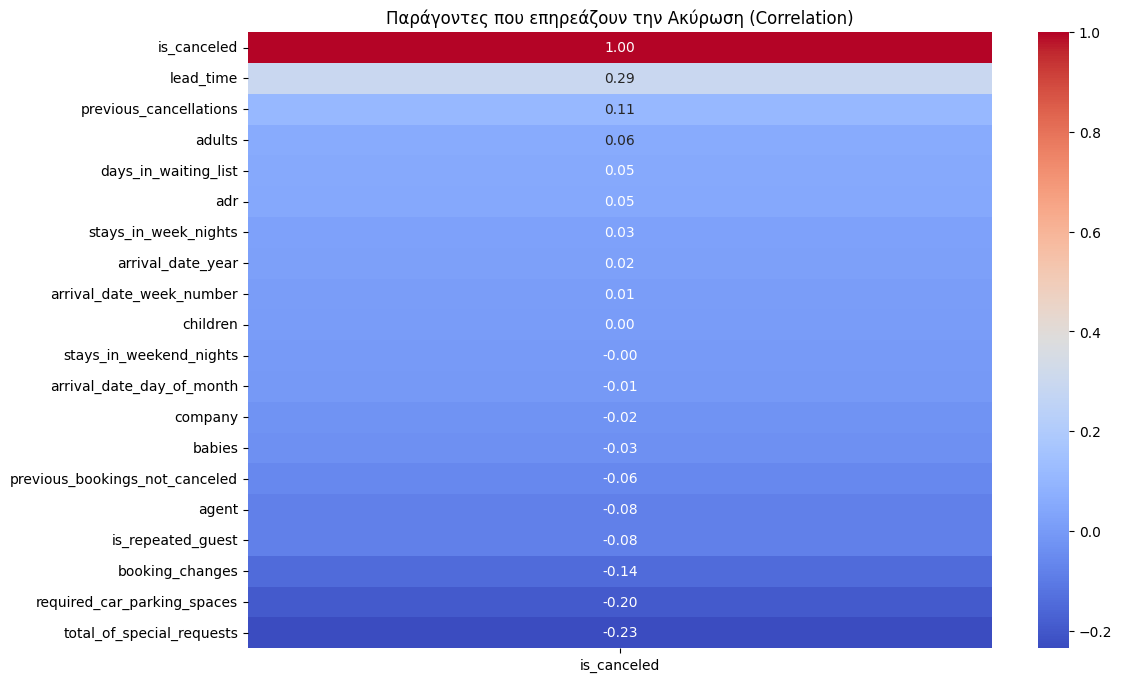

In [9]:
# Υπολογισμός συσχέτισης ΜΟΝΟ για αριθμητικές στήλες (numeric_only=True)
numeric_df = df.select_dtypes(include=[np.number]) # Επιλέγουμε μόνο τους αριθμούς
corr_matrix = numeric_df.corr()

# Συσχέτιση της ακύρωσης με τις υπόλοιπες μεταβλητές
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix[['is_canceled']].sort_values(by='is_canceled', ascending=False), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")
plt.title('Παράγοντες που επηρεάζουν την Ακύρωση (Correlation)')
plt.show()

#### What-if Analysis: Πειραματισμός με Μεταβλητές Απόφασης
Πειραματιζόμαστε με τις Μεταβλητές Απόφασης. Ας εξετάσουμε την επίδραση του lead_time (χρόνος από την κράτηση μέχρι την άφιξη).

In [ ]:
# Χωρίζουμε το lead_time σε κατηγορίες (Μοντελοποίηση)
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=[0, 30, 90, 180, 360, 750], 
                             labels=['0-1 month', '1-3 months', '3-6 months', '6-12 months', '1+ year'])

# Υπολογισμός πιθανότητας ακύρωσης ανά κατηγορία
what_if_lead_time = df.groupby('lead_time_bin')['is_canceled'].mean()
print("Πιθανότητα Ακύρωσης βάσει Lead Time:")
print(what_if_lead_time)

# What-if: Τι θα συμβεί αν μειώσουμε τις κρατήσεις με lead time > 6 μήνες;
what_if_lead_time.plot(kind='bar', color='salmon')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.title('What-if Analysis: Lead Time vs Cancellations')
plt.show()

#### Sensitivity Analysis: Ευαισθησία ως προς τον Τύπο Εγγύησης
Πόσο ευαίσθητο είναι το αποτέλεσμα (Cancellations) στην αλλαγή του deposit_type (Μεταβλητή Απόφασης);

In [ ]:
# Ανάλυση ευαισθησίας ως προς τον τύπο εγγύησης
sensitivity_deposit = df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).unstack()
print(sensitivity_deposit)

# Οπτικοποίηση
sensitivity_deposit.plot(kind='bar', stacked=True)
plt.title('Ευαισθησία Ακυρώσεων ως προς τον Τύπο Εγγύησης')
plt.legend(['Επιβεβαιωμένη', 'Ακυρωμένη'], loc='upper right')
plt.show()

#### Goal Seek Analysis: Προσδιορισμός Στόχου Lead Time
Πόσο πρέπει να μειώσω το lead_time για να πέσουν οι ακυρώσεις στο επιθυμητό επίπεδο;

In [ ]:
# 1. Υπολογίζουμε το μέσο όρο ακυρώσεων για κάθε ημέρα lead_time
lead_time_analysis = df.groupby('lead_time')['is_canceled'].mean().reset_index()

# 2. Εφαρμόζουμε έναν κινητό μέσο όρο (rolling average) για να εξομαλύνουμε τις αυξομειώσεις
# και να δούμε την τάση πιο καθαρά
lead_time_analysis['smoothed_cancellation_rate'] = lead_time_analysis['is_canceled'].rolling(window=10).mean()

# 3. Βρίσκουμε το μέγιστο lead_time όπου η πιθανότητα ακύρωσης παραμένει κάτω από 10% (0.10)
target_rate = 0.20
goal_seek_result = lead_time_analysis[lead_time_analysis['smoothed_cancellation_rate'] <= target_rate].max()

print(f"Στόχος: Ακυρώσεις {target_rate*100}%")
print(f"Απόφαση: Πρέπει να περιορίσουμε το Lead Time το πολύ στις {goal_seek_result['lead_time']:.0f} ημέρες.")

# 4. Οπτικοποίηση του Στόχου
plt.figure(figsize=(12,6))
plt.plot(lead_time_analysis['lead_time'], lead_time_analysis['smoothed_cancellation_rate'], label='Τάση Ακυρώσεων')
plt.axhline(y=target_rate, color='r', linestyle='--', label=f'Στόχος {target_rate*100}%')
plt.axvline(x=goal_seek_result['lead_time'], color='g', linestyle=':', label='Όριο Lead Time')

plt.title('Goal Seek: Εύρεση Μέγιστου Lead Time για 20% Ακυρώσεις')
plt.xlabel('Lead Time (Ημέρες)')
plt.ylabel('Ποσοστό Ακυρώσεων')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Προχωρημένη Ανάλυση: Ιστόγραμμα Lead Time
# ------------------------------------------

# 1. Δημιουργία ιστογράμματος για την κατανομή του lead_time
#    Χωρίζουμε τις τιμές 0-800 σε 100 κουβάδες (bins)
# ax = df.lead_time.hist(bins=np.linspace(0, 800, 100), 
#                   color='blue',              # Χρώμα μπάρας
#                   edgecolor='black',         # Χρώμα περιγράμματος
#                   alpha=0.5,                 # Διαφάνεια (0.5 = 50%)
#                   figsize=(10, 10))          # Μέγεθος γραφήματος


# 2. Μέτρηση συχνότητας lead_time ανά κουβά για προχωρημένη ανάλυση
# lead_counts = df['lead_time'].value_counts(bins=np.linspace(0, 800, 100)).sort_index()

# 3. Εύρεση κορυφών (peaks) στην κατανομή - ανίχνευση προτύπων
#    Χρησιμοποιεί signal processing για να βρει τα "βουνά" της κατανομής
# from scipy.signal import find_peaks
# peaks, _ = find_peaks(lead_counts)
# peaks

# 4. Εμφάνιση των τιμών στις κορυφές
# lead_counts.iloc[peaks]

# 5. Επισήμανση των κορυφών με πορτοκαλί χρώμα στο ιστόγραμμα
#    Αυτό μας δείχνει ποια χρονικά διαστήματα είναι πιο "δημοφιλή"
# for i in peaks:
#     ax.patches[i].set_facecolor('orange')

print("Προχωρημένη ανάλυση lead_time: Ξεσχολιάστε τον κώδικα για να δείτε το ιστόγραμμα.")


#### Προχωρημένη Ανάλυση: Κατανομή του Lead Time (Histogram & Peak Detection)

Τώρα που είδαμε ότι το **lead_time** είναι κρίσιμος παράγοντας (από τη συσχέτιση και το Goal Seek), μπορούμε να εξερευνήσουμε πιο βαθιά την κατανομή του.

**Γιατί είναι σημαντική αυτή η ανάλυση στη Design Phase;**
- Μόλις διαπιστώσαμε ότι το lead_time επηρεάζει δραματικά τις ακυρώσεις
- Τώρα χρειαζόμαστε να καταλάβουμε **πώς κατανέμονται** οι κρατήσεις στον άξονα του χρόνου
- Ποιες περίοδοι κράτησης είναι πιο "δημοφιλείς"; (π.χ. last-minute vs πολύ νωρίς;)

**Τεχνικές που χρησιμοποιούμε:**
1. **Ιστόγραμμα (Histogram):** Οπτικοποιεί πόσες κρατήσεις έγιναν σε κάθε διάστημα ημερών
2. **Ανίχνευση Κορυφών (Peak Detection):** Με signal processing βρίσκουμε τα "βουνά" της κατανομής - τις πιο δημοφιλείς περιόδους κράτησης

**Σημείωση:** Αυτή η ανάλυση είναι προαιρετική και προχωρημένη - απαιτεί τη βιβλιοθήκη `scipy`.

#### Ανάλυση Εποχικότητας (Seasonality Analysis)

Η **εποχικότητα** είναι η τάση των δεδομένων να παρουσιάζουν επαναλαμβανόμενα πρότυπα σε συγκεκριμένες χρονικές περιόδους (π.χ. μήνες, εποχές).

**Γιατί είναι σημαντική για τα DSS;**
- Βοηθά στην **πρόβλεψη ζήτησης**: Αν ξέρουμε ότι το καλοκαίρι έχουμε περισσότερες ακυρώσεις, μπορούμε να προετοιμαστούμε
- **Δυναμική τιμολόγηση**: Σε περιόδους υψηλού ρίσκου, αυξάνουμε τις προκαταβολές ή τις τιμές
- **Προσωπικό & πόροι**: Ξέρουμε πότε χρειαζόμαστε περισσότερο προσωπικό για διαχείριση ακυρώσεων

**Τι εξετάζουμε εδώ:**
Αναλύουμε αν οι ακυρώσεις αυξάνονται σε συγκεκριμένους μήνες (π.χ. το καλοκαίρι, τα Χριστούγεννα). Αν υπάρχει έντονο εποχικό πρότυπο, μπορούμε να προσαρμόσουμε τις πολιτικές μας ανά εποχή.

In [ ]:
# Ορισμός σειράς μηνών για σωστή απεικόνιση
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months, ordered=True)

# Υπολογισμός ποσοστού ακυρώσεων ανά μήνα
seasonal_cancel = df.groupby('arrival_date_month', observed=True)['is_canceled'].mean()

plt.figure(figsize=(12,5))
seasonal_cancel.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Ποσοστό Ακυρώσεων ανά Μήνα (Εποχικότητα)')
plt.ylabel('% Ακυρώσεων')
plt.grid(True, alpha=0.3)
plt.show()

#### Ανάλυση Market Segment (Κατηγοριοποίηση Καναλιών Πώλησης)

Το **Market Segment** αντιπροσωπεύει το "κανάλι" από το οποίο προήλθε η κράτηση:
- **Direct:** Απευθείας από το ξενοδοχείο (τηλέφωνο, ιστοσελίδα)
- **Online Travel Agents (OTA):** Booking.com, Expedia κ.λπ.
- **Groups:** Οργανωμένα γκρουπ, εταιρικά events
- **Corporate:** Εταιρικές συμβάσεις
- **Aviation:** Συνεργασίες με αεροπορικές εταιρείες

**Γιατί διαφέρει το ρίσκο ανά κανάλι;**
- **OTA:** Οι πελάτες συχνά "ψωνίζουν" και συγκρίνουν - μεγαλύτερη πιθανότητα να βρουν καλύτερη προσφορά αλλού
- **Groups:** Υψηλό ρίσκο επειδή αν ακυρώσει ο οργανωτής, χάνονται πολλά δωμάτια
- **Direct:** Χαμηλότερο ρίσκο - ο πελάτης έχει ήδη δεσμευτεί με το brand

**Decision Support:**
Αυτή η ανάλυση μας λέει σε ποια κανάλια πρέπει να εφαρμόσουμε πιο αυστηρές πολιτικές προκαταβολής.

In [ ]:
# Σύγκριση Market Segment και Ακυρώσεων
plt.figure(figsize=(12,6))
sns.barplot(x='market_segment', y='is_canceled', data=df, palette='viridis')
plt.title('Πιθανότητα Ακύρωσης ανά Market Segment')
plt.xticks(rotation=45)
plt.show()

# Insight: Οι κρατήσεις από "Groups" έχουν συνήθως πολύ υψηλότερο ρίσκο.

#### Ανάλυση ADR (Τιμολογιακή Πολιτική)
Εξετάζουμε αν οι ακριβότερες κρατήσεις ακυρώνονται συχνότερα (Sensitivity Analysis στην τιμή).

In [ ]:
# Χωρίζουμε το ADR (τιμή) σε κατηγορίες
df['adr_bin'] = pd.qcut(df['adr'], q=5, labels=['Πολύ Φθηνό', 'Φθηνό', 'Μεσαίο', 'Ακριβό', 'Πολύ Ακριβό'])

# Συσχέτιση τιμής και ακύρωσης
adr_cancel = df.groupby('adr_bin', observed=True)['is_canceled'].mean()

plt.figure(figsize=(10,5))
adr_cancel.plot(kind='bar', color='orchid')
plt.title('Ευαισθησία Ακύρωσης βάσει Τιμής (ADR)')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.show()

#### Ανάλυση Επαναλαμβανόμενων Πελατών (Customer Loyalty Analysis)

Η **πιστότητα πελατών** (Customer Loyalty) είναι ένας κρίσιμος παράγοντας στη Λήψη Αποφάσεων.

**Γιατί οι επαναλαμβανόμενοι πελάτες έχουν διαφορετική συμπεριφορά;**
- **Δέσμευση με το brand:** Έχουν ήδη εμπειρία και εμπιστεύονται το ξενοδοχείο
- **Χαμηλότερο search cost:** Δεν χρειάζεται να ψάχνουν εναλλακτικές - ξέρουν τι θα πάρουν
- **Συναισθηματική σύνδεση:** Ίσως έχουν θετικές αναμνήσεις από προηγούμενες επισκέψεις
- **Loyalty programs:** Συχνά έχουν πόντους ή προνόμια που χάνουν αν ακυρώσουν

**Decision Support - Πολιτική VIP:**
Αν τα δεδομένα δείξουν ότι οι επαναλαμβανόμενοι πελάτες ακυρώνουν σπάνια, μπορούμε να:
1. Τους προσφέρουμε **μειωμένες προκαταβολές** (reward για την πιστότητα)
2. Να επενδύσουμε σε **loyalty programs** για να αυξήσουμε τη διατήρησή τους
3. Να τους δώσουμε **ευέλικτους όρους ακύρωσης** χωρίς να αυξήσουμε το ρίσκο

In [ ]:
# Πιθανότητα ακύρωσης: Νέος vs Επαναλαμβανόμενος Πελάτης
loyalty_cancel = df.groupby('is_repeated_guest')['is_canceled'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=loyalty_cancel.index, y=loyalty_cancel.values)
plt.xticks([0, 1], ['Νέος Πελάτης', 'Επαναλαμβανόμενος'])
plt.title('Επίδραση Πιστότητας στις Ακυρώσεις')
plt.show()

### Οπτικοποίηση Επιπτώσεων: Το Tornado Chart
Το Tornado Chart (Διάγραμμα Ανεμοστρόβιλος) είναι το απόλυτο εργαλείο για την **Ανάλυση Ευαισθησίας (Sensitivity Analysis)** σε ένα παρουσιολόγιο διοίκησης. Βάζει τις μεταβλητές σε σειρά σπουδαιότητας.

**Πώς το διαβάζουμε;**
* **Κόκκινες Μπάρες (Θετική Συσχέτιση):** Όσο αυξάνεται αυτός ο παράγοντας, τόσο *αυξάνεται* η πιθανότητα ακύρωσης (π.χ. Lead Time - όσο πιο νωρίς γίνεται η κράτηση, τόσο πιο πιθανό είναι να ακυρωθεί).
* **Πράσινες Μπάρες (Αρνητική Συσχέτιση):** Όσο αυξάνεται αυτός ο παράγοντας, τόσο *μειώνεται* η πιθανότητα ακύρωσης (είναι οι παράγοντες "ασφαλείας", π.χ. τα ειδικά αιτήματα).

In [ ]:
# 1. Επιλογή μόνο αριθμητικών δεδομένων και υπολογισμός συσχέτισης με το 'is_canceled'
correlations = df.select_dtypes(include=[np.number]).corrwith(df['is_canceled']).drop('is_canceled')

# 2. Ταξινόμηση με βάση το απόλυτο μέγεθος (για να μοιάζει με ανεμοστρόβιλο - Tornado)
# Οι πιο σημαντικές μεταβλητές πάνε πάνω-πάνω
correlations = correlations.reindex(correlations.abs().sort_values(ascending=True).index)

# 3. Δημιουργία χρωμάτων (Κόκκινο για θετική συσχέτιση, Πράσινο για αρνητική)
colors = ['red' if x > 0 else 'green' for x in correlations]

# 4. Σχεδίαση του Tornado Chart
plt.figure(figsize=(10, 8))
plt.barh(correlations.index, correlations.values, color=colors)

# Διαμόρφωση αξόνων
plt.axvline(0, color='black', linewidth=0.8)  # Κάθετη γραμμή στο 0
plt.title('Tornado Chart: Ποιες μεταβλητές επηρεάζουν την Ακύρωση (Sensitivity Analysis)', fontsize=14)
plt.xlabel('Επίδραση (Συσχέτιση)')
plt.ylabel('Μεταβλητές (Παράμετροι)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Εμφάνιση
plt.show()

## Συμπεράσματα & Λήψη Απόφασης (The Choice Phase)
Η μηχανή επεξεργάστηκε τα δεδομένα και παρήγαγε γνώση. Τώρα, ως Manager, καλείστε να πάρετε αποφάσεις. Με βάση την παραπάνω ανάλυση, οι **Προτάσεις Πολιτικής (Policy Recommendations)** είναι:

1. **Αλλαγή Τιμολογιακής Πολιτικής (Deposit):** Είδαμε ότι οι κρατήσεις "Non-Refundable" πρακτικά δεν ακυρώνονται. Πρέπει να προσφέρουμε μεγαλύτερες εκπτώσεις (ADR) σε όσους προπληρώνουν.
2. **Περιορισμός στο Lead Time:** Η ανάλυση "Goal Seek" έδειξε ότι το ρίσκο εκτοξεύεται μετά από ένα όριο ημερών. Μπορούμε να σταματήσουμε να δεχόμαστε κρατήσεις που γίνονται υπερβολικά νωρίς χωρίς προκαταβολή.
3. **Προσοχή στα Groups:** Το Market Segment έδειξε ότι τα γκρουπ έχουν τεράστιο ρίσκο ακύρωσης. Απαιτείται αυστηρότερο συμβόλαιο για αυτές τις κατηγορίες.

*Το Σύστημα Υποστήριξης Αποφάσεων ολοκλήρωσε τον σκοπό του: μετέτρεψε χιλιάδες άγνωστες κρατήσεις σε **3 ξεκάθαρους κανόνες δράσης**!*